# Imports

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the Dataframe

In [48]:
df = pd.read_csv('Bias_correction_ucl.csv')
df.sample(2)

,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
2863,14.0,2014-08-21,25.1,21.7,55.113960,94.274979,28.112578,22.302741,6.841047,14.952015,...,0.0,0.0,0.0,37.4967,126.927,30.9680,0.6180,4786.317871,28.7,21.4
1152,3.0,2013-08-15,32.5,26.1,44.039589,84.804619,33.906595,27.687221,7.497149,14.935814,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5002.308105,31.9,26.2


# Na Fill

In [3]:
print(df.columns)

Index(['station', 'Date', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin',
       'LDAPS_RHmax', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS',
       'LDAPS_LH', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4',
       'LDAPS_PPT1', 'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon',
       'DEM', 'Slope', 'Solar radiation', 'Next_Tmax', 'Next_Tmin'],
      dtype='object')


In [4]:
df.describe()

,station,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
count,7750.000000,7682.000000,7682.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,...,7677.000000,7677.000000,7677.000000,7752.000000,7752.000000,7752.000000,7752.000000,7752.000000,7725.000000,7725.000000
mean,13.000000,29.768211,23.225059,56.759372,88.374804,29.613447,23.512589,7.097875,62.505019,0.368774,...,0.485003,0.278200,0.269407,37.544722,126.991397,61.867972,1.257048,5341.502803,30.274887,22.932220
std,7.211568,2.969999,2.413961,14.668111,7.192004,2.947191,2.345347,2.183836,33.730589,0.262458,...,1.762807,1.161809,1.206214,0.050352,0.079435,54.279780,1.370444,429.158867,3.128010,2.487613
min,1.000000,20.000000,11.300000,19.794666,58.936283,17.624954,14.272646,2.882580,-13.603212,0.000000,...,0.000000,0.000000,0.000000,37.456200,126.826000,12.370000,0.098475,4329.520508,17.400000,11.300000
25%,7.000000,27.800000,21.700000,45.963543,84.222862,27.673499,22.089739,5.678705,37.266753,0.146654,...,0.000000,0.000000,0.000000,37.510200,126.937000,28.700000,0.271300,4999.018555,28.200000,21.300000
50%,13.000000,29.900000,23.400000,55.039024,89.793480,29.703426,23.760199,6.547470,56.865482,0.315697,...,0.000000,0.000000,0.000000,37.550700,126.995000,45.716000,0.618000,5436.345215,30.500000,23.100000
75%,19.000000,32.000000,24.900000,67.190056,93.743629,31.710450,25.152909,8.032276,84.223616,0.575489,...,0.018364,0.007896,0.000041,37.577600,127.042000,59.832400,1.767800,5728.316406,32.600000,24.600000
max,25.000000,37.600000,29.900000,98.524734,100.000153,38.542255,29.619342,21.857621,213.414006,0.967277,...,21.621661,15.841235,16.655469,37.645000,127.135000,212.335000,5.178230,5992.895996,38.900000,29.800000


In [49]:
df.isnull().sum()

station              2
Date                 2
Present_Tmax        70
Present_Tmin        70
LDAPS_RHmin         75
LDAPS_RHmax         75
LDAPS_Tmax_lapse    75
LDAPS_Tmin_lapse    75
LDAPS_WS            75
LDAPS_LH            75
LDAPS_CC1           75
LDAPS_CC2           75
LDAPS_CC3           75
LDAPS_CC4           75
LDAPS_PPT1          75
LDAPS_PPT2          75
LDAPS_PPT3          75
LDAPS_PPT4          75
lat                  0
lon                  0
DEM                  0
Slope                0
Solar radiation      0
Next_Tmax           27
Next_Tmin           27
dtype: int64

In [57]:
df.isnull().sum()/len(df)*100

station             0.0
Date                0.0
Present_Tmax        0.0
Present_Tmin        0.0
LDAPS_RHmin         0.0
LDAPS_RHmax         0.0
LDAPS_Tmax_lapse    0.0
LDAPS_Tmin_lapse    0.0
LDAPS_WS            0.0
LDAPS_LH            0.0
LDAPS_CC1           0.0
LDAPS_CC2           0.0
LDAPS_CC3           0.0
LDAPS_CC4           0.0
LDAPS_PPT1          0.0
LDAPS_PPT2          0.0
LDAPS_PPT3          0.0
LDAPS_PPT4          0.0
lat                 0.0
lon                 0.0
DEM                 0.0
Slope               0.0
Solar radiation     0.0
Next_Tmax           0.0
Next_Tmin           0.0
dtype: float64

All less than 1

For more information, read [Cho et al, 2020].
1. station - used weather station number: 1 to 25
2. Date - Present day: yyyy-mm-dd ('2013-06-30' to '2017-08-30')
3. Present_Tmax - Maximum air temperature between 0 and 21 h on the present day (Â°C): 20 to 37.6
4. Present_Tmin - Minimum air temperature between 0 and 21 h on the present day (Â°C): 11.3 to 29.9
5. LDAPS_RHmin - LDAPS model forecast of next-day minimum relative humidity (%): 19.8 to 98.5
6. LDAPS_RHmax - LDAPS model forecast of next-day maximum relative humidity (%): 58.9 to 100
7. LDAPS_Tmax_lapse - LDAPS model forecast of next-day maximum air temperature applied lapse rate (Â°C): 17.6 to 38.5
8. LDAPS_Tmin_lapse - LDAPS model forecast of next-day minimum air temperature applied lapse rate (Â°C): 14.3 to 29.6
9. LDAPS_WS - LDAPS model forecast of next-day average wind speed (m/s): 2.9 to 21.9
10. LDAPS_LH - LDAPS model forecast of next-day average latent heat flux (W/m2): -13.6 to 213.4
11. LDAPS_CC1 - LDAPS model forecast of next-day 1st 6-hour split average cloud cover (0-5 h) (%): 0 to 0.97
12. LDAPS_CC2 - LDAPS model forecast of next-day 2nd 6-hour split average cloud cover (6-11 h) (%): 0 to 0.97
13. LDAPS_CC3 - LDAPS model forecast of next-day 3rd 6-hour split average cloud cover (12-17 h) (%): 0 to 0.98
14. LDAPS_CC4 - LDAPS model forecast of next-day 4th 6-hour split average cloud cover (18-23 h) (%): 0 to 0.97
15. LDAPS_PPT1 - LDAPS model forecast of next-day 1st 6-hour split average precipitation (0-5 h) (%): 0 to 23.7
16. LDAPS_PPT2 - LDAPS model forecast of next-day 2nd 6-hour split average precipitation (6-11 h) (%): 0 to 21.6
17. LDAPS_PPT3 - LDAPS model forecast of next-day 3rd 6-hour split average precipitation (12-17 h) (%): 0 to 15.8
18. LDAPS_PPT4 - LDAPS model forecast of next-day 4th 6-hour split average precipitation (18-23 h) (%): 0 to 16.7
19. lat - Latitude (Â°): 37.456 to 37.645
20. lon - Longitude (Â°): 126.826 to 127.135
21. DEM - Elevation (m): 12.4 to 212.3
22. Slope - Slope (Â°): 0.1 to 5.2
23. Solar radiation - Daily incoming solar radiation (wh/m2): 4329.5 to 5992.9
24. Next_Tmax - The next-day maximum air temperature (Â°C): 17.4 to 38.9
25. Next_Tmin - The next-day minimum air temperature (Â°C): 11.3 to 29.8


In [51]:
# Drop Date null row
df.dropna(subset=['Date'], inplace=True)
df["Date"].isnull().sum()

0

In [52]:
# Check If We can fill Station As Estimate Near to lon,lat
df[df["station"].isnull()]

,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin


array([[<Axes: title={'center': 'station'}>,
        <Axes: title={'center': 'Present_Tmax'}>,
        <Axes: title={'center': 'Present_Tmin'}>,
        <Axes: title={'center': 'LDAPS_RHmin'}>,
        <Axes: title={'center': 'LDAPS_RHmax'}>],
       [<Axes: title={'center': 'LDAPS_Tmax_lapse'}>,
        <Axes: title={'center': 'LDAPS_Tmin_lapse'}>,
        <Axes: title={'center': 'LDAPS_WS'}>,
        <Axes: title={'center': 'LDAPS_LH'}>,
        <Axes: title={'center': 'LDAPS_CC1'}>],
       [<Axes: title={'center': 'LDAPS_CC2'}>,
        <Axes: title={'center': 'LDAPS_CC3'}>,
        <Axes: title={'center': 'LDAPS_CC4'}>,
        <Axes: title={'center': 'LDAPS_PPT1'}>,
        <Axes: title={'center': 'LDAPS_PPT2'}>],
       [<Axes: title={'center': 'LDAPS_PPT3'}>,
        <Axes: title={'center': 'LDAPS_PPT4'}>,
        <Axes: title={'center': 'lat'}>, <Axes: title={'center': 'lon'}>,
        <Axes: title={'center': 'DEM'}>],
       [<Axes: title={'center': 'Slope'}>,
        <Axes: 

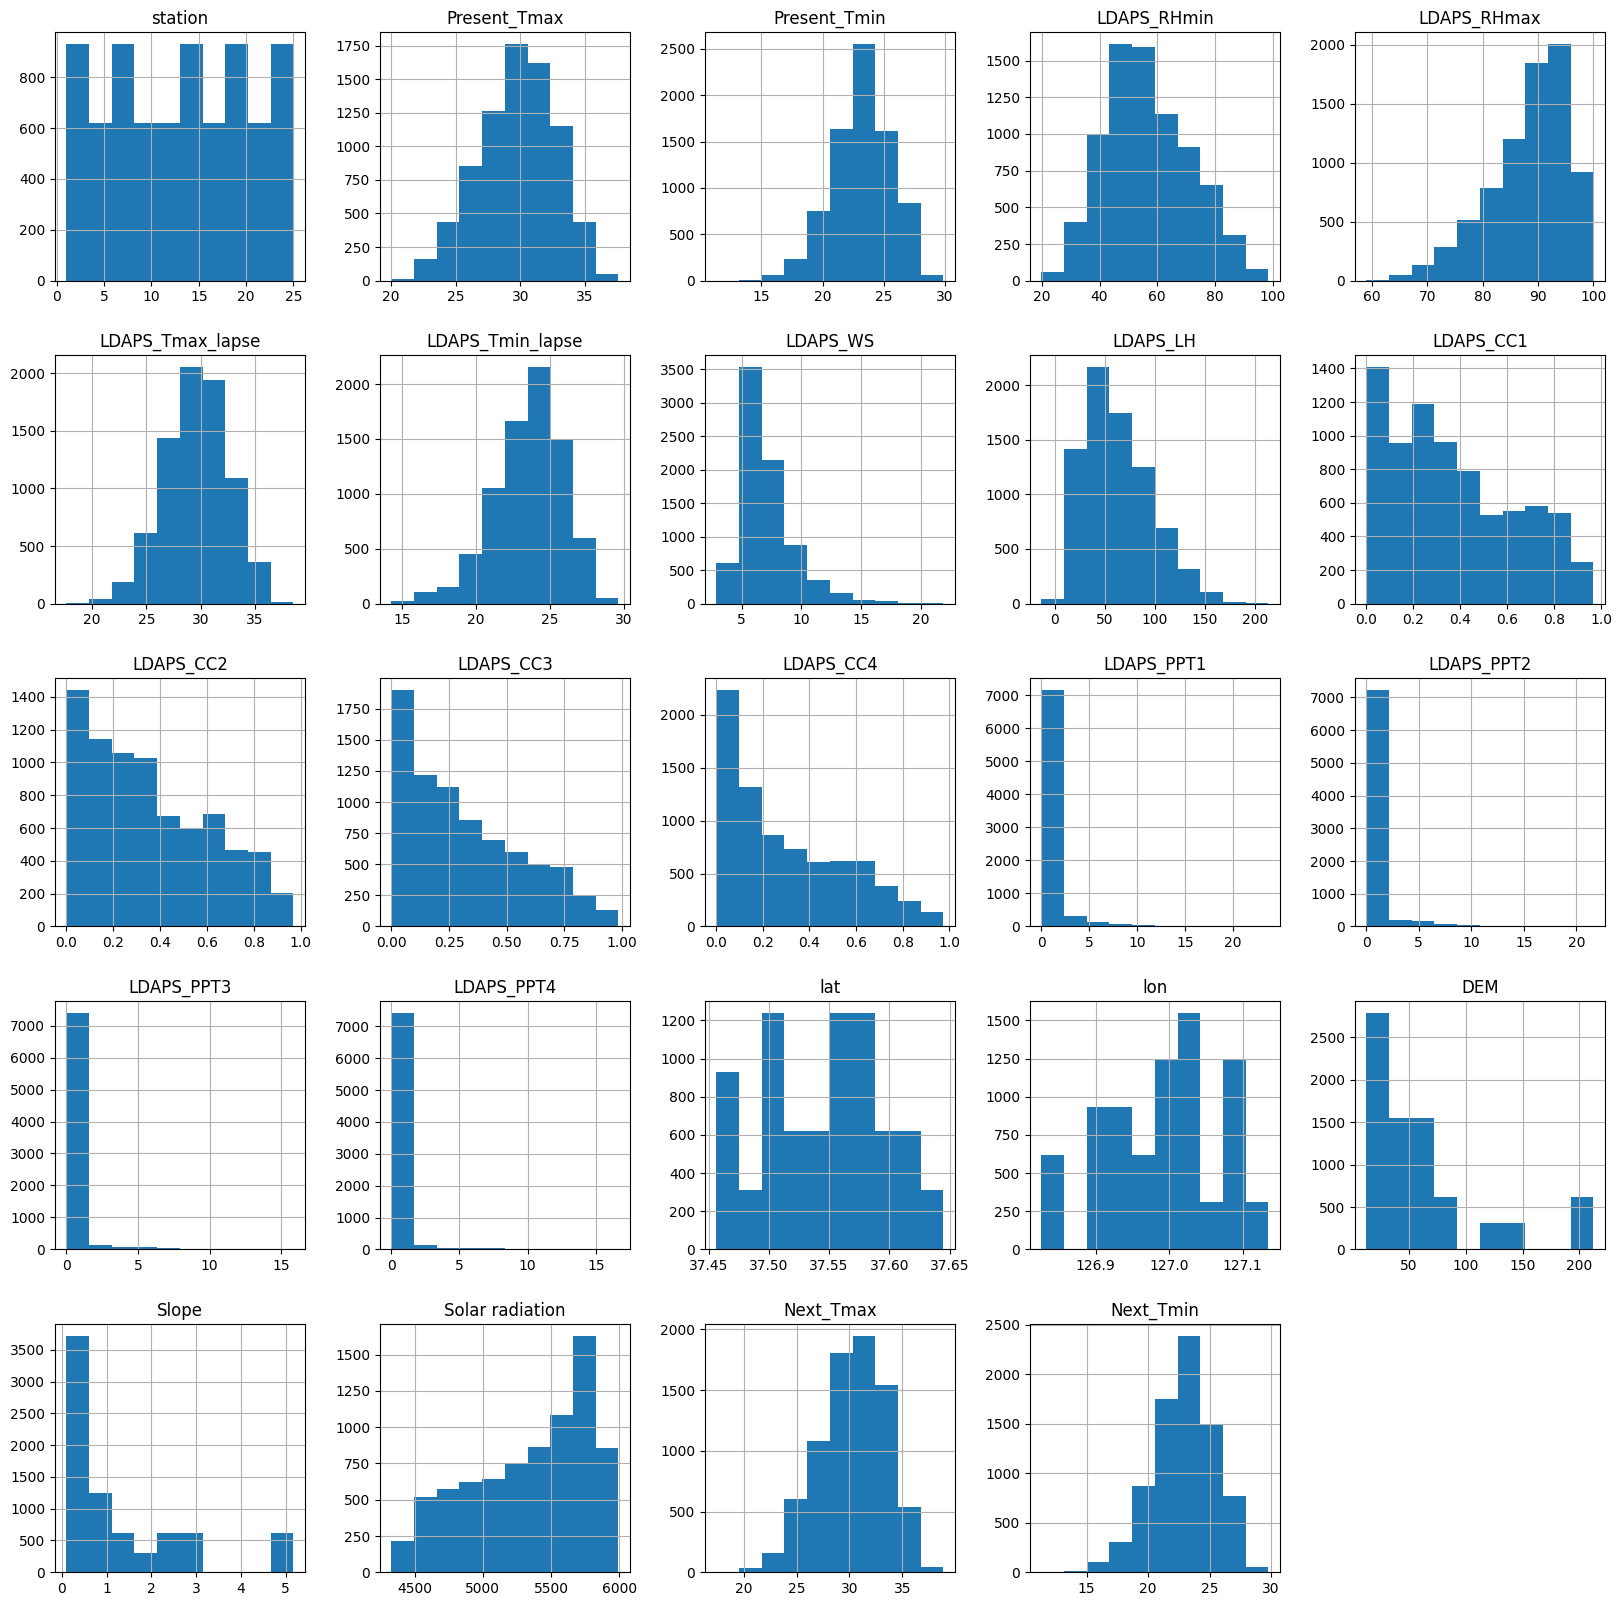

In [58]:
df.hist(figsize=(20,20))

- If skewed = use median
- If normal = use mean

In [54]:
# 4. Zero fill (precipitation)
ppt_cols = [
    "LDAPS_PPT1", "LDAPS_PPT2", "LDAPS_PPT3", "LDAPS_PPT4"
]

for col in ppt_cols:
    print(f"{col}: {df[df[col]==0][col].count()/len(df)*100:.2f}% zero values")

LDAPS_PPT1: 62.49% zero values
LDAPS_PPT2: 66.45% zero values
LDAPS_PPT3: 68.30% zero values
LDAPS_PPT4: 74.19% zero values


In [55]:
# 4. Zero fill (precipitation)
ppt_cols = [
    "LDAPS_PPT1", "LDAPS_PPT2", "LDAPS_PPT3", "LDAPS_PPT4"
]

for col in ppt_cols:
    df[col].fillna(0, inplace=True)

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\1289628022.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)


Interepolation

In [56]:
df = df.sort_values(["station","Date"])
df = df.groupby("station").apply(lambda x: x.interpolate(method="linear", limit_direction="both")).reset_index(drop=True)

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\1878937619.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.groupby("station").apply(lambda x: x.interpolate(method="linear", limit_direction="both")).reset_index(drop=True)
C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\1878937619.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.groupby("station").apply(lambda x: x.interpolate(method="linear", limit_direction="both")).reset_index(drop=True)
C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\1878937619.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.groupby("station").apply(lambda

In [61]:
df.isna().sum().sum()

0

# EDA

In [114]:
print(df.columns)

Index(['station', 'Date', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin',
       'LDAPS_RHmax', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS',
       'LDAPS_LH', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4',
       'LDAPS_PPT1', 'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon',
       'DEM', 'Slope', 'Solar radiation', 'Next_Tmax', 'Next_Tmin', 'CC_mean',
       'CC_std', 'CC_max', 'CC_min', 'CC_trend', 'error_tmax', 'error_tmin',
       'PPT_sum', 'PPT_max', 'rain_flag'],
      dtype='object')


In [112]:
cloud_cols = [
    "LDAPS_CC1", "LDAPS_CC2", "LDAPS_CC3", "LDAPS_CC4"
]

df["CC_mean"] = df[cloud_cols].mean(axis=1)
df["CC_std"]  = df[cloud_cols].std(axis=1)
df["CC_max"]  = df[cloud_cols].max(axis=1)
df["CC_min"]  = df[cloud_cols].min(axis=1)
df["CC_trend"] = df["LDAPS_CC4"] - df["LDAPS_CC1"]

In [113]:
ppt_cols = ["LDAPS_PPT1","LDAPS_PPT2","LDAPS_PPT3","LDAPS_PPT4"]

df["PPT_sum"] = df[ppt_cols].sum(axis=1)
df["PPT_max"] = df[ppt_cols].max(axis=1)

# rain flag (important)
df["rain_flag"] = (df["PPT_sum"] > 0).astype(int)

# Error Analysis

In [70]:
# This is model bias (residual)
df['error_tmax'] = df['Next_Tmax'] - df['LDAPS_Tmax_lapse']
df['error_tmin'] = df['Next_Tmin'] - df['LDAPS_Tmin_lapse']

<Axes: >

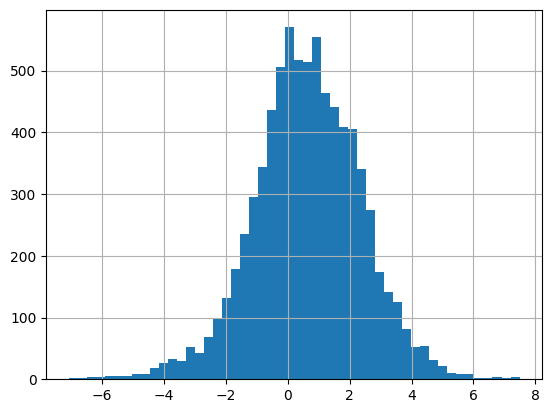

In [71]:
df["error_tmax"].hist(bins=50)

underprediction on Tmax

In [75]:
df["error_tmax"].describe()

count    7750.000000
mean        0.641526
std         1.751705
min        -7.068596
25%        -0.442821
50%         0.645384
75%         1.809744
max         7.487189
Name: error_tmax, dtype: float64

Check TMax Against All

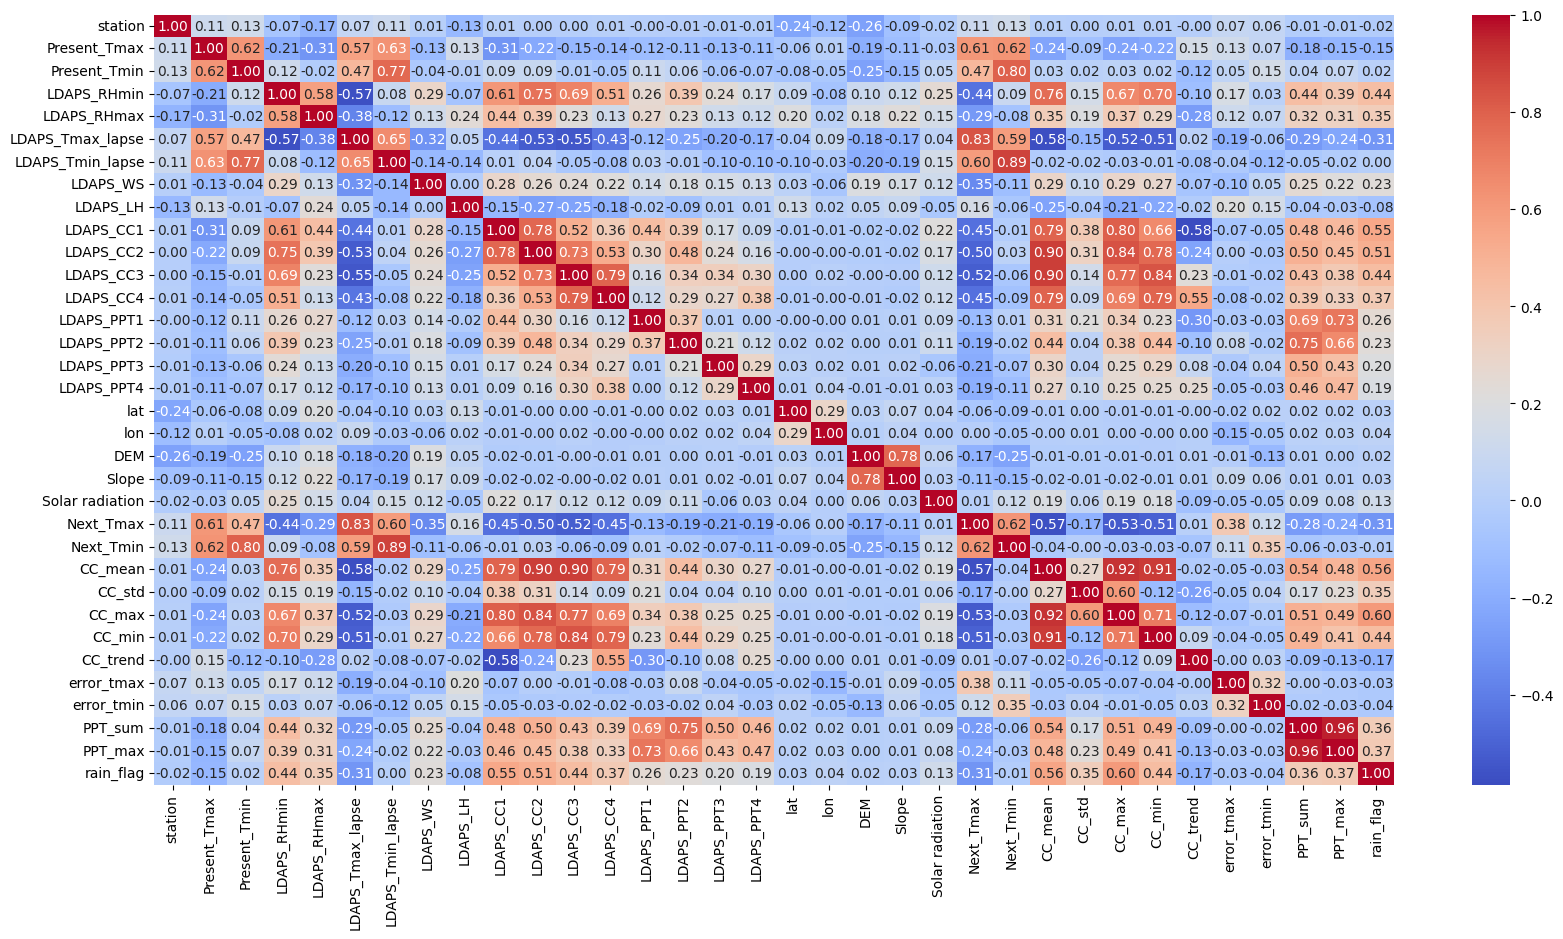

In [111]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

- LDAPS is slightly underpredicting Tmax on average
- But variance is large → unstable model

<Axes: xlabel='Next_Tmax', ylabel='error_tmax'>

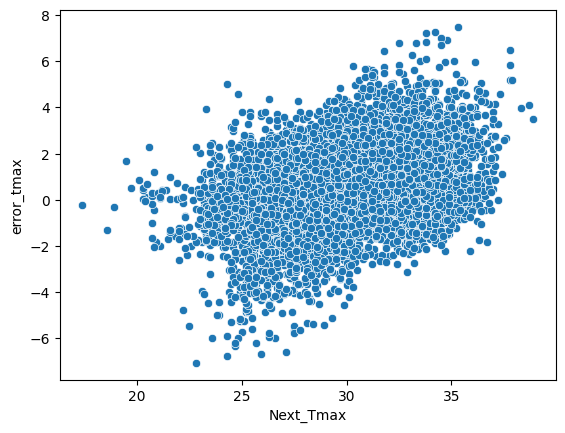

In [95]:
sns.scatterplot(x=df["Next_Tmax"], y=df["error_tmax"])

- High humidity → more clouds → cooling
- LDAPS predicts higher temp → overprediction

<Axes: xlabel='LDAPS_RHmax', ylabel='error_tmax'>

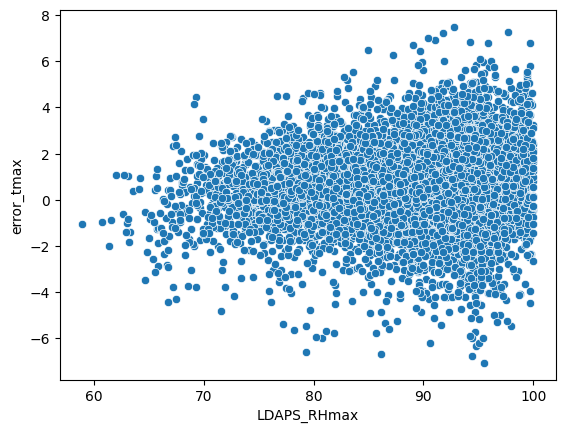

In [84]:
sns.scatterplot(x=df["LDAPS_RHmax"], y=df["error_tmax"])

No relations

<Axes: xlabel='CC_mean', ylabel='error_tmax'>

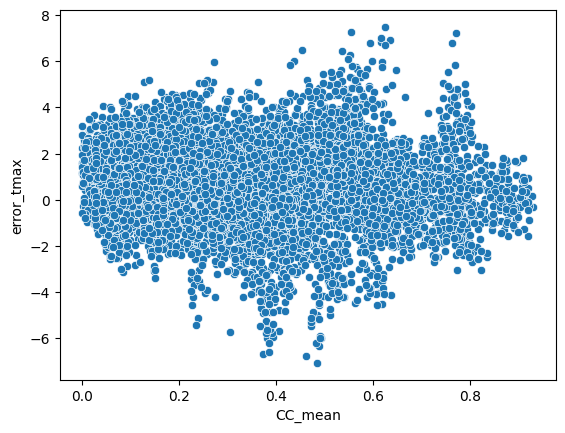

In [85]:
sns.scatterplot(x=df["CC_mean"], y=df["error_tmax"])

- Rain causes sudden cooling
- LDAPS fails to model intensity properly

<Axes: xlabel='rain_flag', ylabel='error_tmax'>

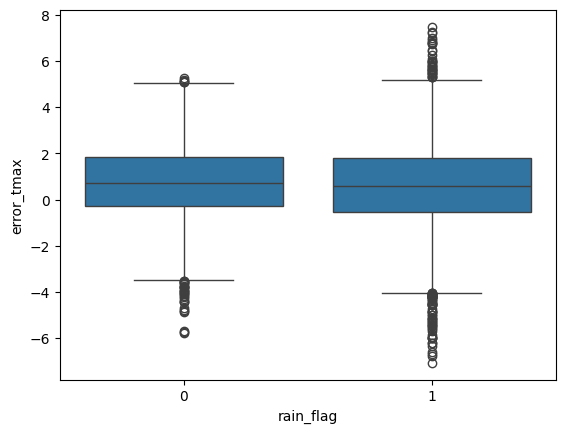

In [90]:
sns.boxplot(x=df["rain_flag"], y=df["error_tmax"])

Low wind more errors. predict high temp. 

<Axes: xlabel='LDAPS_WS', ylabel='error_tmax'>

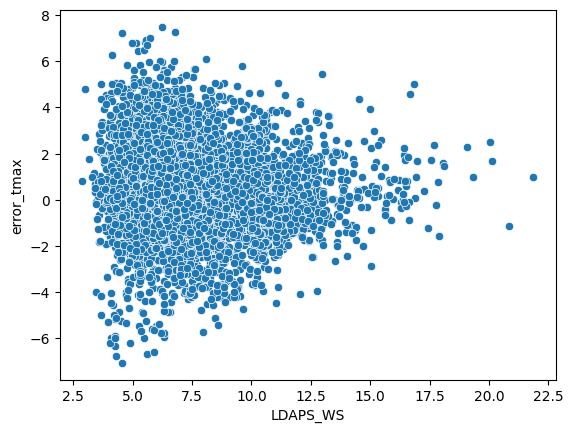

In [91]:
sns.scatterplot(x=df["LDAPS_WS"], y=df["error_tmax"])

Takes more temprature when heat_wave

<Axes: xlabel='LDAPS_LH', ylabel='error_tmax'>

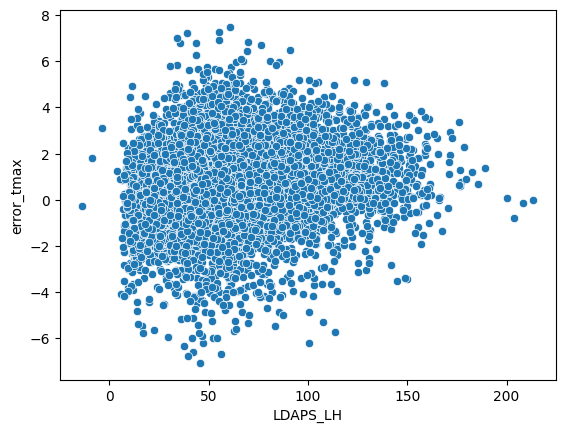

In [117]:
sns.scatterplot(x=df["LDAPS_LH"], y=df["error_tmax"])

## Feature Creation

Temprature Analysis with Error

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\317127445.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_error = df.groupby("temp_bin")["error_tmax"].mean()


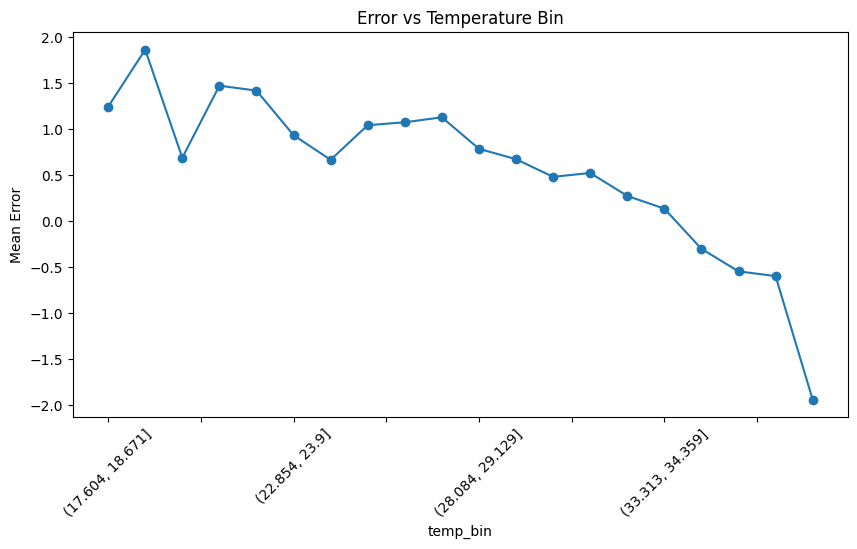

In [115]:
df["temp_bin"] = pd.cut(df["LDAPS_Tmax_lapse"], bins=20)
bin_error = df.groupby("temp_bin")["error_tmax"].mean()
bin_error.plot(figsize=(10,5), marker='o')
plt.xticks(rotation=45)
plt.ylabel("Mean Error")
plt.title("Error vs Temperature Bin")
plt.show()

In [116]:
threshold = 32  # from analysis

df["heat_excess"] = np.maximum(0, df["LDAPS_Tmax_lapse"] - threshold)

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\857212282.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_error = df.groupby("LDAPS_LH_bin")["error_tmax"].mean()


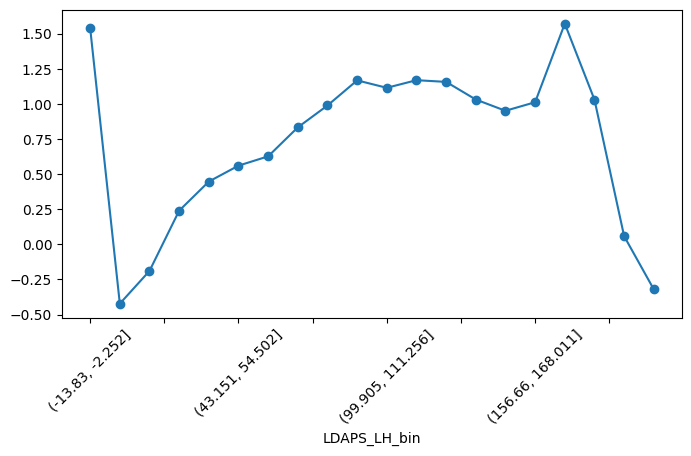

In [119]:
df["LDAPS_LH_bin"] = pd.cut(df["LDAPS_LH"], bins=20)
bin_error = df.groupby("LDAPS_LH_bin")["error_tmax"].mean()

bin_error.plot(marker='o', figsize=(8,4))
plt.xticks(rotation=45)
plt.show()

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\4061106912.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_error = df.groupby("LDAPS_WS_bin")["error_tmax"].mean()


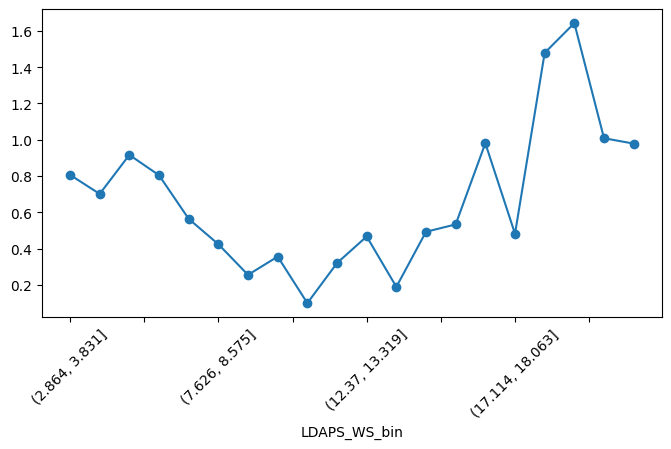

In [120]:
df["LDAPS_WS_bin"] = pd.cut(df["LDAPS_WS"], bins=20)
bin_error = df.groupby("LDAPS_WS_bin")["error_tmax"].mean()

bin_error.plot(marker='o', figsize=(8,4))
plt.xticks(rotation=45)
plt.show()

In [121]:
threshold = 16  # from analysis
df["wind_excess"] = np.maximum(0, df["LDAPS_WS"] - threshold)

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\3117196547.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ppt_bin")["error_tmax"].mean().plot(marker='o')


<Axes: xlabel='ppt_bin'>

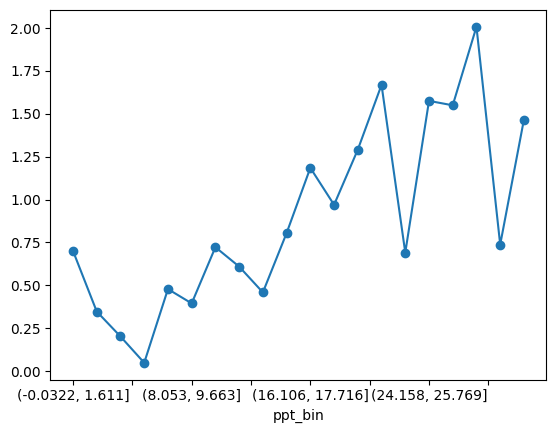

In [122]:
df["ppt_bin"] = pd.cut(df["PPT_sum"], bins=20)
df.groupby("ppt_bin")["error_tmax"].mean().plot(marker='o')

In [123]:
df["rain_intensity"] = np.log1p(df["PPT_sum"])

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\3598627245.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cc_bin")["error_tmax"].mean().plot(marker='o')


<Axes: xlabel='cc_bin'>

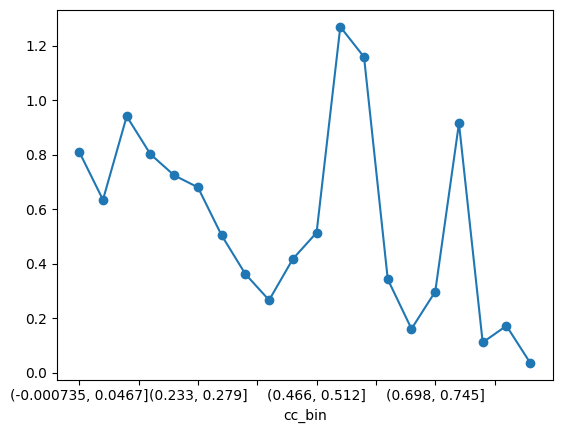

In [124]:
df["cc_bin"] = pd.cut(df["CC_mean"], bins=20)
df.groupby("cc_bin")["error_tmax"].mean().plot(marker='o')

In [125]:
threshold = 0.5  # from analysis
df["cloud_excess"] = np.maximum(0, df["CC_mean"] - threshold)

C:\Users\hs250\AppData\Local\Temp\ipykernel_31316\1323267352.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("rh_bin")["error_tmax"].mean().plot(marker='o')


<Axes: xlabel='rh_bin'>

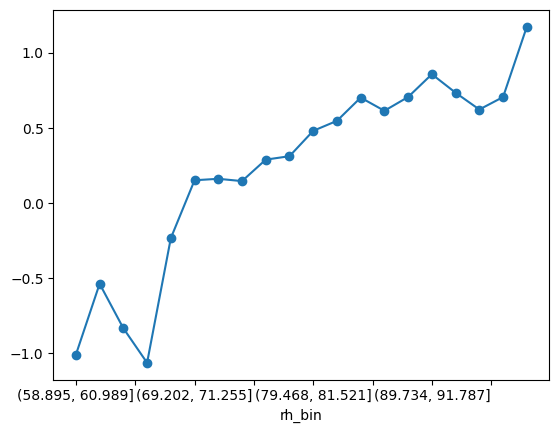

In [127]:
df["rh_bin"] = pd.cut(df["LDAPS_RHmax"], bins=20)
df.groupby("rh_bin")["error_tmax"].mean().plot(marker='o')

In [128]:
threshold = 70  # from analysis
df["humidity_excess"] = np.maximum(0, df["LDAPS_RHmax"] - threshold)

In [131]:
from sklearn.preprocessing import StandardScaler

cols = ["cloud_excess", "humidity_excess", "wind_excess", "rain_intensity"]

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

df["cooling_effect"] = df[cols].sum(axis=1)

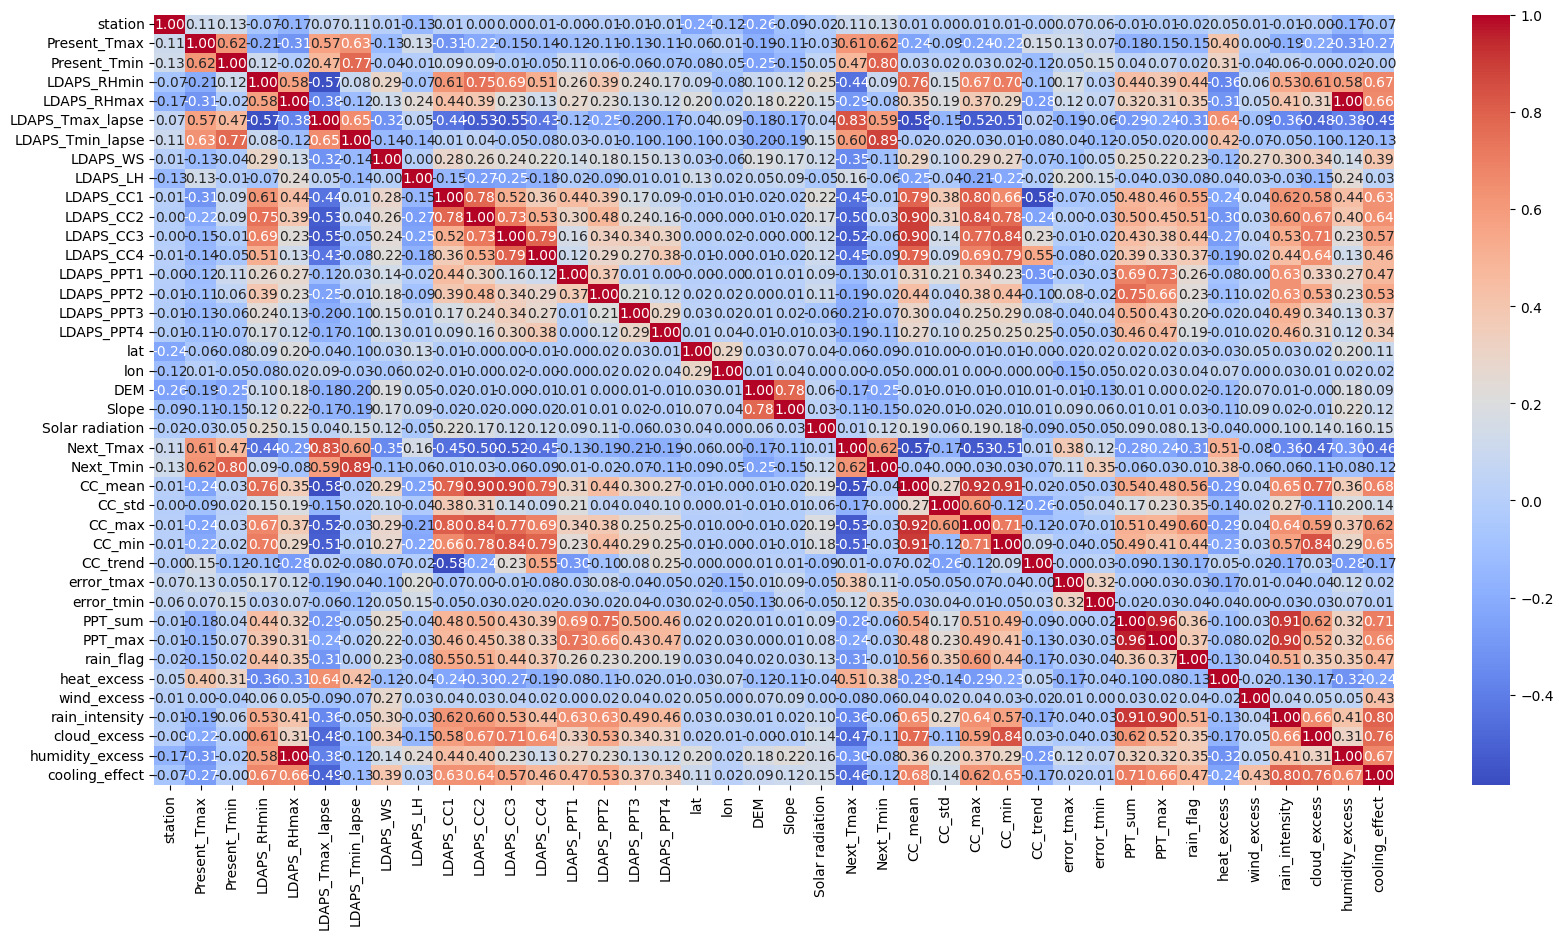

In [132]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()